# Weather ML Project - Exploratory Data Analysis

Notebook này thực hiện EDA cho weather forecasting project.

**Nội dung:**
1. Load & Inspect Data
2. Data Quality Check
3. Statistical Analysis
4. Visualization
5. Feature Correlations
6. Seasonal Patterns

In [11]:
# Setup
import sys
import os
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import CITIES, PROCESSED_DATA_FILE
from visualization.plots import setup_dark_theme

# Setup plotting
setup_dark_theme()
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load Data

In [2]:
# Load processed data
df = pd.read_csv(PROCESSED_DATA_FILE, parse_dates=['Date'])

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (9135, 17)

Columns: ['Date', 'TempMax', 'TempMean', 'TempMin', 'Precipitation', 'WindSpeed', 'City', 'Humidity', 'Year', 'Month', 'Day', 'DayOfYear', 'Quarter', 'DaylightHours', 'TempLag1', 'TempLag3', 'City_encoded']


,Date,TempMax,TempMean,TempMin,Precipitation,WindSpeed,City,Humidity,Year,Month,Day,DayOfYear,Quarter,DaylightHours,TempLag1,TempLag3,City_encoded
0,2020-01-01,2.7,1.5,-1.1,0.0,14.6,Amsterdam,97.583333,2020,1,1,1,1,7.55,11.229682,11.234759,0
1,2020-01-02,6.8,3.7,1.5,0.0,23.7,Amsterdam,94.291667,2020,1,2,2,1,7.57,1.500000,11.234759,0
2,2020-01-03,9.8,8.0,5.6,5.2,28.7,Amsterdam,86.541667,2020,1,3,3,1,7.59,3.700000,11.234759,0
3,2020-01-04,8.4,7.1,5.4,0.0,27.5,Amsterdam,86.833333,2020,1,4,4,1,7.61,8.000000,1.500000,0
4,2020-01-05,8.3,6.7,5.3,0.5,18.9,Amsterdam,91.208333,2020,1,5,5,1,7.63,7.100000,3.700000,0


## 2. Data Quality

In [3]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Data types
print("\nData types:")
print(df.dtypes)

Missing values:
Date             0
TempMax          0
TempMean         0
TempMin          0
Precipitation    0
WindSpeed        0
City             0
Humidity         0
Year             0
Month            0
Day              0
DayOfYear        0
Quarter          0
DaylightHours    0
TempLag1         0
TempLag3         0
City_encoded     0
dtype: int64

Data types:
Date             datetime64[ns]
TempMax                 float64
TempMean                float64
TempMin                 float64
Precipitation           float64
WindSpeed               float64
City                     object
Humidity                float64
Year                      int64
Month                     int64
Day                       int64
DayOfYear                 int64
Quarter                   int64
DaylightHours           float64
TempLag1                float64
TempLag3                float64
City_encoded              int64
dtype: object


## 3. Statistical Summary

In [4]:
# Describe numerical columns
df.describe()

,Date,TempMax,TempMean,TempMin,Precipitation,WindSpeed,Humidity,Year,Month,Day,DayOfYear,Quarter,DaylightHours,TempLag1,TempLag3,City_encoded
count,9135,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000,9135.000000
mean,2022-07-02 00:00:00,15.638971,11.754176,7.914669,2.251341,17.584784,74.946438,2022.000000,6.521073,15.735085,183.200328,2.507937,11.995345,11.759157,11.767939,2.000000
min,2020-01-01 00:00:00,-11.200000,-14.900000,-18.200000,0.000000,1.800000,23.000000,2020.000000,1.000000,1.000000,1.000000,1.000000,5.740000,-14.900000,-14.900000,0.000000
25%,2021-04-01 00:00:00,9.000000,5.800000,2.400000,0.000000,12.600000,66.875000,2021.000000,4.000000,8.000000,92.000000,2.000000,9.440000,5.800000,5.900000,1.000000
50%,2022-07-02 00:00:00,15.600000,11.700000,7.900000,0.200000,16.600000,77.541667,2022.000000,7.000000,16.000000,183.000000,3.000000,12.000000,11.700000,11.700000,2.000000
75%,2023-10-02 00:00:00,21.800000,17.500000,13.200000,2.400000,21.300000,85.291667,2023.000000,10.000000,23.000000,275.000000,4.000000,14.560000,17.500000,17.500000,3.000000
max,2024-12-31 00:00:00,43.500000,35.100000,29.100000,51.400000,60.900000,100.000000,2024.000000,12.000000,31.000000,366.000000,4.000000,18.260000,35.100000,35.100000,4.000000
std,NaN,8.818270,7.974930,7.427468,4.543807,7.149343,14.081098,1.415065,3.449401,8.802873,105.487842,1.117332,3.085836,7.971834,7.967324,1.414291


In [5]:
# Records per city
print("Records per city:")
print(df['City'].value_counts())

Records per city:
City
Amsterdam    1827
Athens       1827
Berlin       1827
Stockholm    1827
Zurich       1827
Name: count, dtype: int64


## 4. Temperature Analysis

In [6]:
# Temperature stats by city
temp_stats = df.groupby('City')[['TempMax', 'TempMean', 'TempMin']].agg(['mean', 'std', 'min', 'max'])
temp_stats

TempMax                         TempMean                        \
                mean       std   min   max       mean       std   min   max   
City                                                                          
Amsterdam  14.496497  6.367988  -3.8  34.0  11.226875  5.680467  -6.8  26.6   
Athens     22.576355  8.092186   3.5  43.5  18.210290  7.464694   0.8  35.1   
Berlin     14.891297  8.550185  -7.2  37.7  10.988560  7.536185 -10.2  30.0   
Stockholm  11.286097  8.587879 -11.2  32.2   7.715928  7.748621 -14.9  24.8   
Zurich     14.944609  8.162626  -3.7  34.0  10.629228  7.291147  -7.2  27.0   

             TempMin                        
                mean       std   min   max  
City                                        
Amsterdam   7.933114  5.352657 -11.4  21.8  
Athens     14.032567  6.994812  -2.3  29.1  
Berlin      7.011275  6.750515 -14.9  22.2  
Stockholm   4.051122  7.258746 -18.2  19.0  
Zurich      6.545265  6.711373 -11.0  20.8

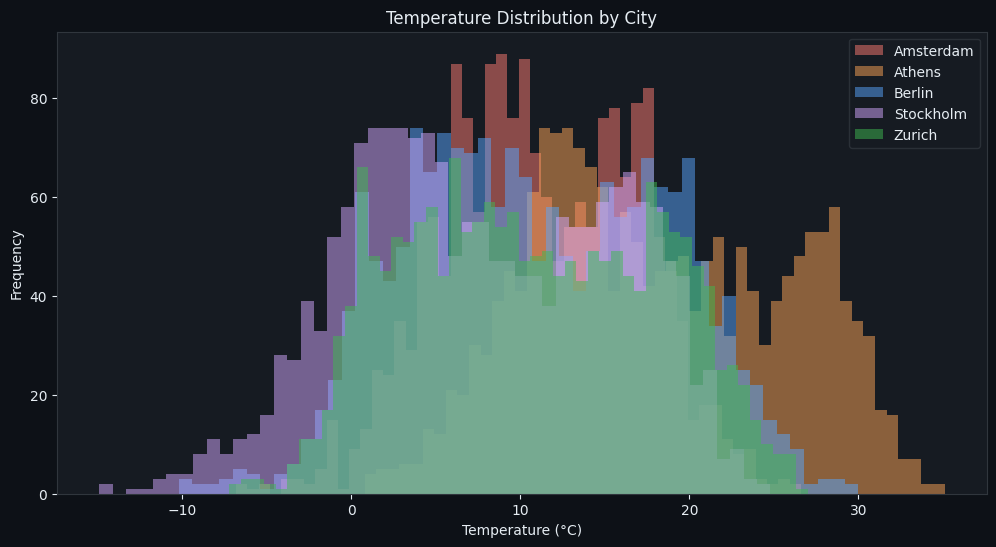

In [7]:
# Temperature distribution by city
fig, ax = plt.subplots(figsize=(12, 6))

for city in sorted(df['City'].unique()):
    city_data = df[df['City'] == city]['TempMean']
    ax.hist(city_data, bins=50, alpha=0.5, label=city, color=CITIES[city]['mau'])

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency')
ax.set_title('Temperature Distribution by City')
ax.legend()
plt.show()

## 5. Correlation Analysis

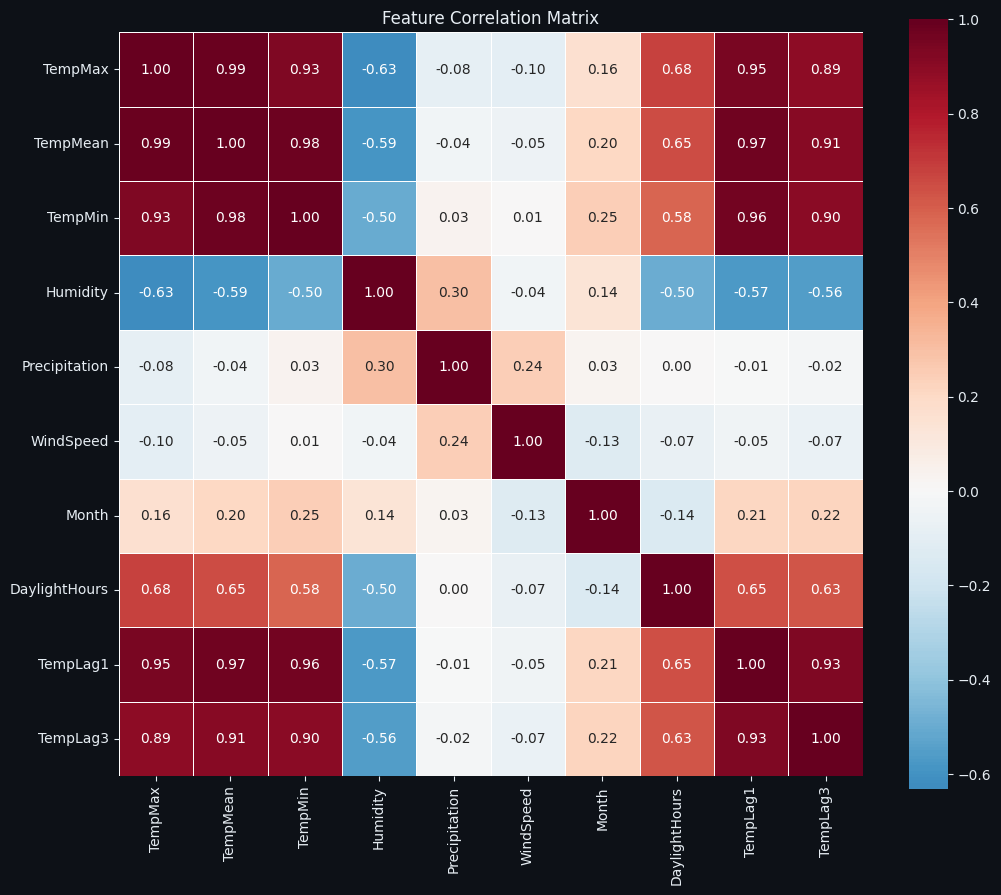

In [8]:
# Correlation matrix
numerical_cols = ['TempMax', 'TempMean', 'TempMin', 'Humidity', 'Precipitation', 
                  'WindSpeed', 'Month', 'DaylightHours', 'TempLag1', 'TempLag3']

corr = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.show()

## 6. Seasonal Patterns

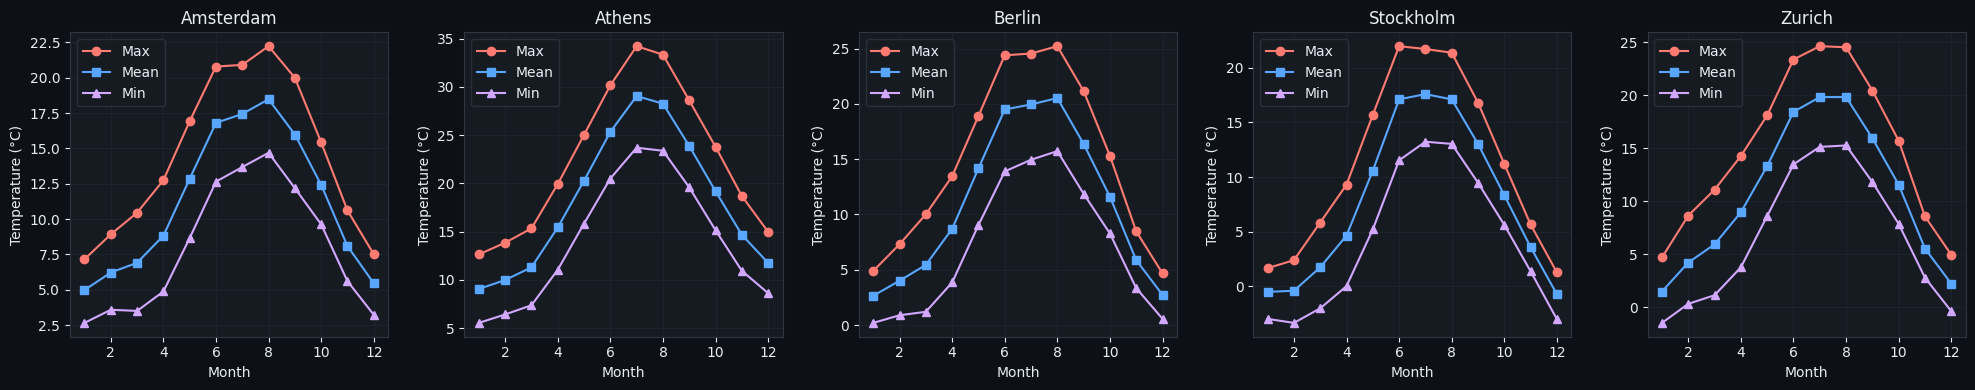

In [9]:
# Monthly temperature patterns
monthly_temps = df.groupby(['City', 'Month']).agg({
    'TempMax': 'mean',
    'TempMean': 'mean',
    'TempMin': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, city in enumerate(sorted(df['City'].unique())):
    city_data = monthly_temps[monthly_temps['City'] == city]
    ax = axes[i]
    
    ax.plot(city_data['Month'], city_data['TempMax'], 'o-', label='Max', color='#ff7b72')
    ax.plot(city_data['Month'], city_data['TempMean'], 's-', label='Mean', color='#58a6ff')
    ax.plot(city_data['Month'], city_data['TempMin'], '^-', label='Min', color='#d2a8ff')
    
    ax.set_title(city)
    ax.set_xlabel('Month')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 7. Feature Distributions

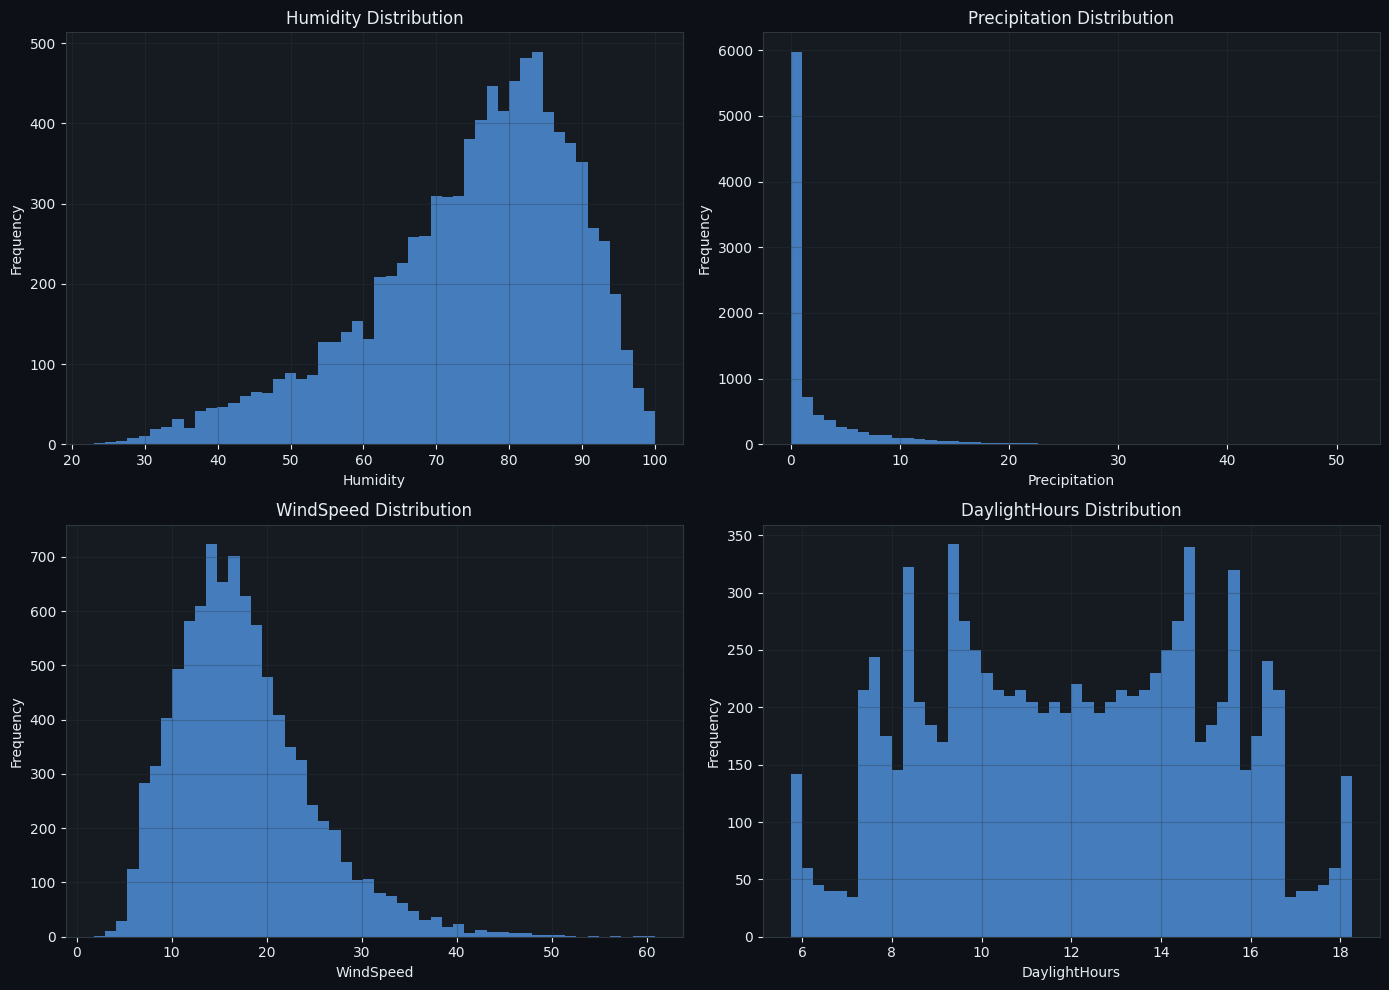

In [10]:
# Distribution of key features
features = ['Humidity', 'Precipitation', 'WindSpeed', 'DaylightHours']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.hist(df[feature], bins=50, color='#58a6ff', alpha=0.7)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Phần tiếp theo:
Lựa chọn models training sau khi có cài nhìn toàn diện về dữ liệu.
